In [ ]:
# Logan Cheng w/ partners Oscar and Alexis
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("Mobile Phone Classification")
print("=" * 60)
print()

Mobile Phone Classification



In [44]:
# Read CSV in pandas
df = pd.read_csv("train.csv")
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [45]:
# X = input features (all columns except price_range)
X = df.drop("price_range", axis=1)
# y = target variable
y = df['price_range']

In [46]:
# Split dataset into training (80%) a d testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print()

print("Class balance check:")
print(f" Training: {dict(y_train.value_counts())}")
print(f" Testing: {dict(y_test.value_counts())}")
print(" (Should be roughly proportional)")
print()

# Initialize scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled with StandardScaler.")
print()

Training samples: 1600
Testing samples: 400

Class balance check:
 Training: {1: np.int64(400), 0: np.int64(400), 3: np.int64(400), 2: np.int64(400)}
 Testing: {3: np.int64(100), 1: np.int64(100), 0: np.int64(100), 2: np.int64(100)}
 (Should be roughly proportional)

Features scaled with StandardScaler.



Overall Accuracy: 51.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       100
           1       0.36      0.39      0.37       100
           2       0.38      0.38      0.38       100
           3       0.72      0.59      0.65       100

    accuracy                           0.52       400
   macro avg       0.53      0.52      0.52       400
weighted avg       0.53      0.52      0.52       400



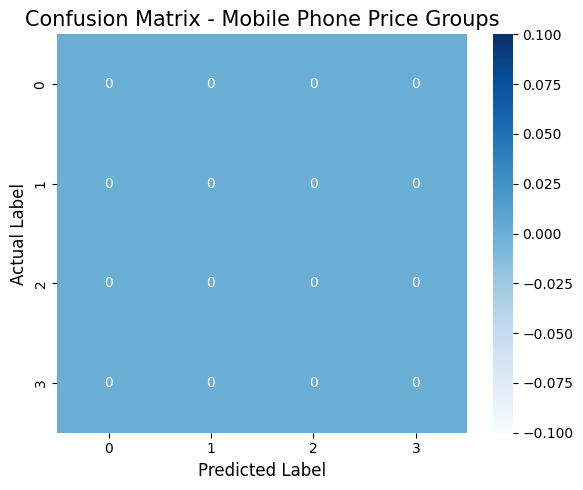

In [47]:
# Create KNN model
knn = KNeighborsClassifier(n_neighbors=7)
# Train the model using scaled training data
knn.fit(X_train_scaled, y_train)

# Predict price categories for test data
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
# Print Overall Accuracy scores
print(f"Overall Accuracy: {accuracy:.2%}")
print()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(
    y_test, y_pred,
    labels=['0', '1', '2', '3']             # define labels
)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap='Blues',
    xticklabels=['0', '1', '2', '3'],
    yticklabels=['0', '1', '2', '3']
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix - Mobile Phone Price Groups', fontsize=15)
plt.tight_layout()
plt.show()



In [48]:
# Test K 1 to 31
k_range = range(1, 31)

cv_means = []   # Average accuracy
cv_stds = []    # Standard deviation

for k in k_range:
    # Create a model with this K
    model = KNeighborsClassifier(n_neighbors=k)
    
    # Run a 5-fold cross-validation on the TRAINING data only
    # Cross_val_score returns an array of a 5 accuracy scores
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Store the meand and standard deviation
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

    if k % 5 == 0 or k == 1:
        print(f"    K={k:02} -> CV Accuracy = {scores.mean():.2%} (±{scores.std():.2%})")

print()


    K=01 -> CV Accuracy = 45.88% (±3.08%)
    K=05 -> CV Accuracy = 49.81% (±3.28%)
    K=10 -> CV Accuracy = 53.94% (±1.49%)
    K=15 -> CV Accuracy = 57.00% (±3.02%)
    K=20 -> CV Accuracy = 58.13% (±3.12%)
    K=25 -> CV Accuracy = 58.00% (±3.10%)
    K=30 -> CV Accuracy = 60.00% (±3.63%)



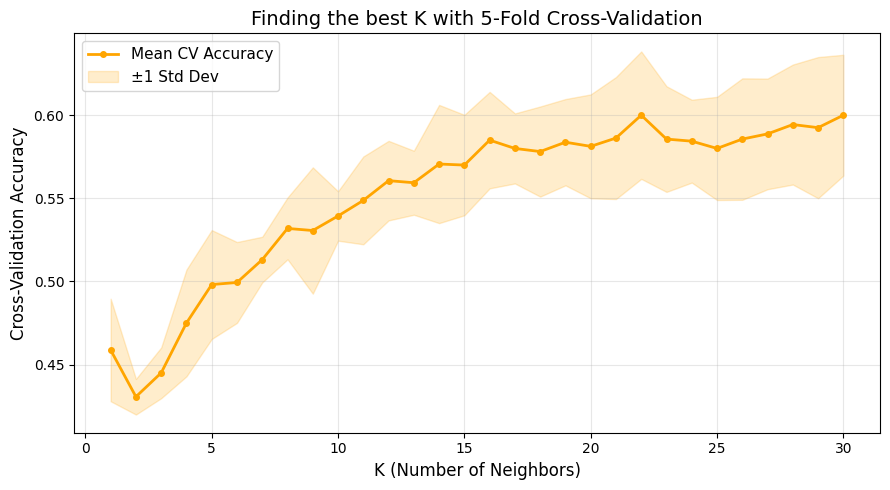

    -> Best K = 22
    -> Best CV Accuracy = 60.00%



In [49]:
# Plot the results
plt.figure(figsize=(9, 5))

# Convert to numpy arrays
cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
k_list = list(k_range)

# Main line (mean accuracy)
plt.plot(k_list, cv_means, marker='o', color='#FFA500',
         linewidth=2, markersize=4, label="Mean CV Accuracy")

# Shaded region (±1 standard deviation)
# This shows the UNCERTAINTY in our accuracy estimate)
plt.fill_between(
    k_list,
    cv_means - cv_stds,
    cv_means + cv_stds,
    alpha=0.2,
    color='#FFA500',
    label='±1 Std Dev'
)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding the best K with 5-Fold Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find the best K
best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print(f"    -> Best K = {best_k}")
print(f"    -> Best CV Accuracy = {best_cv_accuracy:.2%}")
print()

In [50]:
# Retrain with the best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Final predictions on the test set
y_pred_final = final_model.predict(X_test_scaled)

# Final accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Test Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

# Final classification report
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Test Accuracy (K=22): 61.25%

Final Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       100
           1       0.51      0.54      0.52       100
           2       0.47      0.49      0.48       100
           3       0.75      0.63      0.68       100

    accuracy                           0.61       400
   macro avg       0.62      0.61      0.61       400
weighted avg       0.62      0.61      0.61       400



In [ ]:
# Three new phones
new_phones = pd.DataFrame({
   'battery_power':    [650, 1400, 1900],
    'blue':             [0, 1, 1],
    'clock_speed':      [1.3, 2.0, 2.7],
    'dual_sim':         [1, 1, 0],
    'fc':               [1, 4, 10],
    'four_g':           [0, 1, 1],
    'int_memory':       [8, 32, 128],
    'm_dep':            [0.4, 0.7, 0.9],
    'mobile_wt':        [195, 165, 140],
    'n_cores':          [2, 4, 8],
    'pc':               [2, 8, 20],
    'px_height':        [300, 900, 1800],
    'px_width':         [800, 1600, 3000],
    'ram':              [700, 2200, 3900],
    'sc_h':             [10, 15, 20],
    'sc_w':             [6, 10, 14],
    'talk_time':        [8, 15, 22],
    'three_g':          [0, 1, 1],
    'touch_screen':     [0, 1, 1],
    'wifi':             [0, 1, 1]
})

print("New mobile phone devices")
print(new_phones.to_string(index=False))
print()

new_scaled = scaler.transform(new_phones)

# Get predictions and probabilities
predictions = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

# Display the results for each mobile device
class_labels = final_model.classes_

for i in range(len(new_phones)):
    print(f"Phone #{1+1}:")
    print(f" Predicted phone price: {predictions[i]}")
    print(f" Confidence breakdown:")

    for cls, prob in zip(class_labels, probabilities[i]):
        # Visual bar to make probabilities easier to read
        bar_length = int(prob * 25)
        bar = '█' * bar_length + '░' * (25 - bar_length)
        print(f" {str(class_labels[cls]):10s} {bar} {prob:6.1%}")
    print()

print()

New mobile phone devices
 battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  mobile_wt  n_cores  pc  px_height  px_width  ram  sc_h  sc_w  talk_time  three_g  touch_screen  wifi
           650     0          1.3         1   1       0           8    0.4        195        2   2        300       800  700    10     6          8        0             0     0
          1400     1          2.0         1   4       1          32    0.7        165        4   8        900      1600 2200    15    10         15        1             1     1
          1900     1          2.7         0  10       1         128    0.9        140        8  20       1800      3000 3900    20    14         22        1             1     1

Phone #2:
 Predicted phone price: 0
 Confidence breakdown:
 0          ██████████████░░░░░░░░░░░  59.1%
 1          ███████░░░░░░░░░░░░░░░░░░  31.8%
 2          ██░░░░░░░░░░░░░░░░░░░░░░░   9.1%
 3          ░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%

Phone #2:
 Predicted phone

In this project, we used a K-Nearest Neighbors model to classify mobile phones into different price ranges based on their features. We started by loading the dataset, separating the input features and target variable, and splitting the data into training and testing sets. After that, we scaled the data so the model could perform better. We trained the KNN model and checked how well it worked using accuracy, a classification report, and a confusion matrix. Then, instead of sticking with one K value, we tested multiple values from 1 to 30 using cross-validation to see which one gave the best results. Once we found the best K, we retrained the model and evaluated it again on the test data. Finally, we used the model to predict price categories for a few new phone examples and looked at the probability of each prediction to understand how confident the model was.

https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification